# EX 5: Introduction to classification and pattern recognition</center>


## Background
The normal sleep-wake cycle of an adult consists of 3 main sleep stages: the awake stage, non-rapid eye movement stage (NREM) and rapid eye movement stage (REM). The NREM stage is further subdivided into transitional sleep (N1), light sleep (N2) and deep sleep (N3). A graph representing the clinically labelled sleep stages of this recording, called a hypnogram, is plotted in Figure 1.

Analysis of the sleep-wake cycling plays a crucial role in the diagnosis of sleep disorders (e.g. sleep apnea or insomnia). The patient with sleep problems is typically admitted to the sleep lab, where an overnight polysomnography is recorded. Every 30s epoch of this polysomnography is then visually labelled by a sleep specialist according to the sleep scoring criteria by the American Academy of Sleep Medicine. However, manually labelling these long recordings is a tedious, time-consuming and error-prone task. Therefore, automated classification of sleep-wake cycling is of great interest.

In this exercise session, we will explore the **classification of sleep stages** based on features derived from a single-channel EEG recording and lay the fundamentals of creating a pipeline for classification. Next session, more advanced examples and techniques will be explored.


<p align="center">
  <img src="https://drive.google.com/uc?id=1rcB7pYV6o522KHxKgJm-dBuWVdqaDNIR" />
</p>
<p align="center">
    <em>Figure 1. Sleep stages as a function of time</em>
</p>


## Notes
- Many Python functions have several possible inputs and outputs. Check the full documentation, as some useful outputs and optional parameters might not be included in the first possible function call.
- Don’t forget the titles and axis labels in your figures!

# EX 5.1 : Descriptive statistics

## Background
One of the first steps in a classification problem is to extract discriminative features from the data. The power in the main frequency bands of the EEG is often used to automatically classify sleep stages. As such, the relative power in the delta, theta, alpha and beta band is extracted from the EEG signal, for every 30s epoch. We have already extracted these features from the data for this exercise session.

After performing feature extraction, **descriptive statistics can provide simple summaries about the data and about the observations (features)**. These summaries may form the basis of the initial description of the data as part of a more extensive statistical analysis. Such summaries may be either visual, i.e. simple-to-understand graphs, or quantitative, i.e. measuring the mean, standard deviation.



In [33]:
import numpy as np
import itertools
import pandas as pd
import matplotlib.pyplot as plt
import os
%matplotlib inline
import zipfile

## 1.1 Data loading

A preprocessed EEG signal is provided, originally being 8 h 33 min long and sampled at 500 Hz. From the EEG signal, the DC component was removed and normalized by dividing it by its standard deviation. Then, the signal was segmented into epochs of 30s without overlap. Subsequently, the power spectral density for each EEG segment was estimated using Welch’s method and the relative power in the different bands was computed. The bands are as following: delta (δ: 0.5-4Hz), theta (θ: 4-8Hz), alpha (α: 8-13Hz) and beta (β: 13-35Hz) band. The relative power is the ratio of the power in a specific frequency band (δ, θ, α, or β) to the total power of the signal in the frequency band of interest (in this case: 0.5-35Hz).

**Load the EEG features** from `features.npy` and the clinical annotations (sleep stages) from `labels.npy`, both being numpy arrays. The features matrix is a matrix $𝑋\in\mathbb{R}^{𝑆\times 𝐹}$, where S refers to the number of epochs of 30s (Samples) and F to the number of Features (F = 4). The clinical annotations are labelled as follows:
- N3: label = 1
- N2: label = 2
- N1: label = 3
- REM: label = 4
- Wake: label = 5


**Check how many features (F) and how many samples (S) are in the dataset.**

In [34]:

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [35]:
base_path = "/content/drive/MyDrive/Colab Notebooks/Biomedical Data Processing/new /EX5: Introduction to classification and pattern recognition"
zip_path = os.path.join(base_path, "data.zip")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(base_path)

print("Extracted files:")
print(os.listdir(base_path))

Extracted files:
['5.1. Descriptive statistics.ipynb', '5.2. Unsupervised Classification.ipynb', '5.3. Supervised classification.ipynb', 'data.zip', 'EEG_sleep', 'EEG_sleep_supervised']


In [36]:
sleep_path = os.path.join(base_path, "EEG_sleep")
sup_path   = os.path.join(base_path, "EEG_sleep_supervised")

print("EEG_SLEEP:", os.listdir(sleep_path))
print("EEG_SLEEP_SUPERVISED:", os.listdir(sup_path))


EEG_SLEEP: ['features.npy', 'labels.npy']
EEG_SLEEP_SUPERVISED: ['feat_test.npy', 'feat_train.npy', 'labels_test.npy', 'labels_train.npy']


In [37]:
# Load the features and labels
# features = np.load('features.npy')
# labels = np.load('labels.npy')
features = np.load(os.path.join(sleep_path, "features.npy"))
labels   = np.load(os.path.join(sleep_path, "labels.npy"))
labels = np.squeeze(labels)

# features is a numpy array with shape (n_samples, n_features)
# labels is a numpy array with shape (n_samples,)

print(features, features.shape)
print(labels, labels.shape)

# Define the names of the features and the classes.
feature_names = ['Relative Delta power','Relative Theta power','Relative Alpha power','Relative Beta power']
sleep_stages = ['N3','N2','N1','REM','Wake']

[[-1.46191566 -1.5010528  -1.47646705  2.48126252]
 [ 1.3430578  -1.98996591 -1.91849654 -0.4174545 ]
 [ 0.82336493 -1.40047083 -1.5178862  -0.1181919 ]
 ...
 [-0.94790772  1.29882765  0.21047252  0.59063583]
 [-0.54798103  0.15478108  1.24472578  0.28225901]
 [-0.99539705  0.35649881  0.37938277  0.91732991]] (1026, 4)
[5 5 5 ... 5 5 5] (1026,)


## 1.2 Feature visualization

Visualize the feature values belonging to each class (N3, N2, N1, REM and wake), similarly to Figure 9.1 p. 576 in the book. More specific, **make scatter plots of all possible feature combinations**. This should be 1 figure with 6 subfigures (all possible feature pair combinations for 4 different features), where the data points of the different sleep stages (different labels) are indicated in a different color. Do not forget to add a legend.
- Which sleep stages are easiest to discriminate?
- Is it possible to find a linear separation between the classes?

Some useful functions:
- from the package *matplotlib.pyplot*:
    - **subplot**: create a figure with subplots
    - **scatter**: create a scatter plot
    - **suptitle**: put a main title for a figure with subplots
- from the package *itertools*:
    - **combinations**: get a list of all combinations of a certain length from a given list

(Hint: try to make the code as modular as possible, avoid hardcoding, so that you can reuse this code.)

(Remark: to get a scatter plot with empty circles from the function `matplotlib.pyplot.scatter`, specify parameter `c` to be `None` and give a color value to parameter `edgecolor`, e.g. using the default colors given by function `plt.cm.tab10(index)`)

In [ ]:
# Get all feature combinations (with indices of the features).

def get_feature_pairs(n_features, max_plots=None):
    """
    Generate all 2-feature combinations, optionally limiting the number.
    """
    pairs = list(itertools.combinations(range(n_features), 2))
    if max_plots is not None:
        pairs = pairs[:max_plots]
    return pairs

# Go with a for loop through the combinations and visualize the features (make 1 figure with 6 subplots).

def plot_feature_pairs(
    features,
    labels,
    feature_names,
    sleep_stages,
    feature_pairs,
    cmap_name='tab10',
    ncols=3,
    figsize=(18, 12)
):
    """
    Plot scatter plots for each feature pair, colored by sleep stage.
    """

    colors = plt.colormaps.get_cmap(cmap_name)
    n_plots = len(feature_pairs)
    nrows = int(np.ceil(n_plots / ncols))

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
    axes = axes.flatten()

    for i, (f1_idx, f2_idx) in enumerate(feature_pairs):
        ax = axes[i]

        for j, stage in enumerate(sleep_stages):
            stage_data = features[labels == (j + 1)]

            ax.scatter(
                stage_data[:, f1_idx],
                stage_data[:, f2_idx],
                c=None,
                edgecolor=colors(j),
                label=stage,
                alpha=0.6,
                s=20
            )

        ax.set_title(f"{feature_names[f1_idx]} vs {feature_names[f2_idx]}")
        ax.set_xlabel(feature_names[f1_idx])
        ax.set_ylabel(feature_names[f2_idx])
        ax.grid(True, linestyle='--', alpha=0.7)

        # Show legend only in first plot for cleanliness
        if i == 0:
            ax.legend()

    # Turn off empty subplots if any
    for k in range(n_plots, len(axes)):
        axes[k].axis("off")

    fig.suptitle("Scatter Plots of Feature Combinations by Sleep Stage", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    return fig


def visualize_all_feature_pairs(features, labels, feature_names, sleep_stages, max_plots=6):
    n_features = features.shape[1]
    pairs = get_feature_pairs(n_features, max_plots=max_plots)

    return plot_feature_pairs(
        features=features,
        labels=labels,
        feature_names=feature_names,
        sleep_stages=sleep_stages,
        feature_pairs=pairs
    )


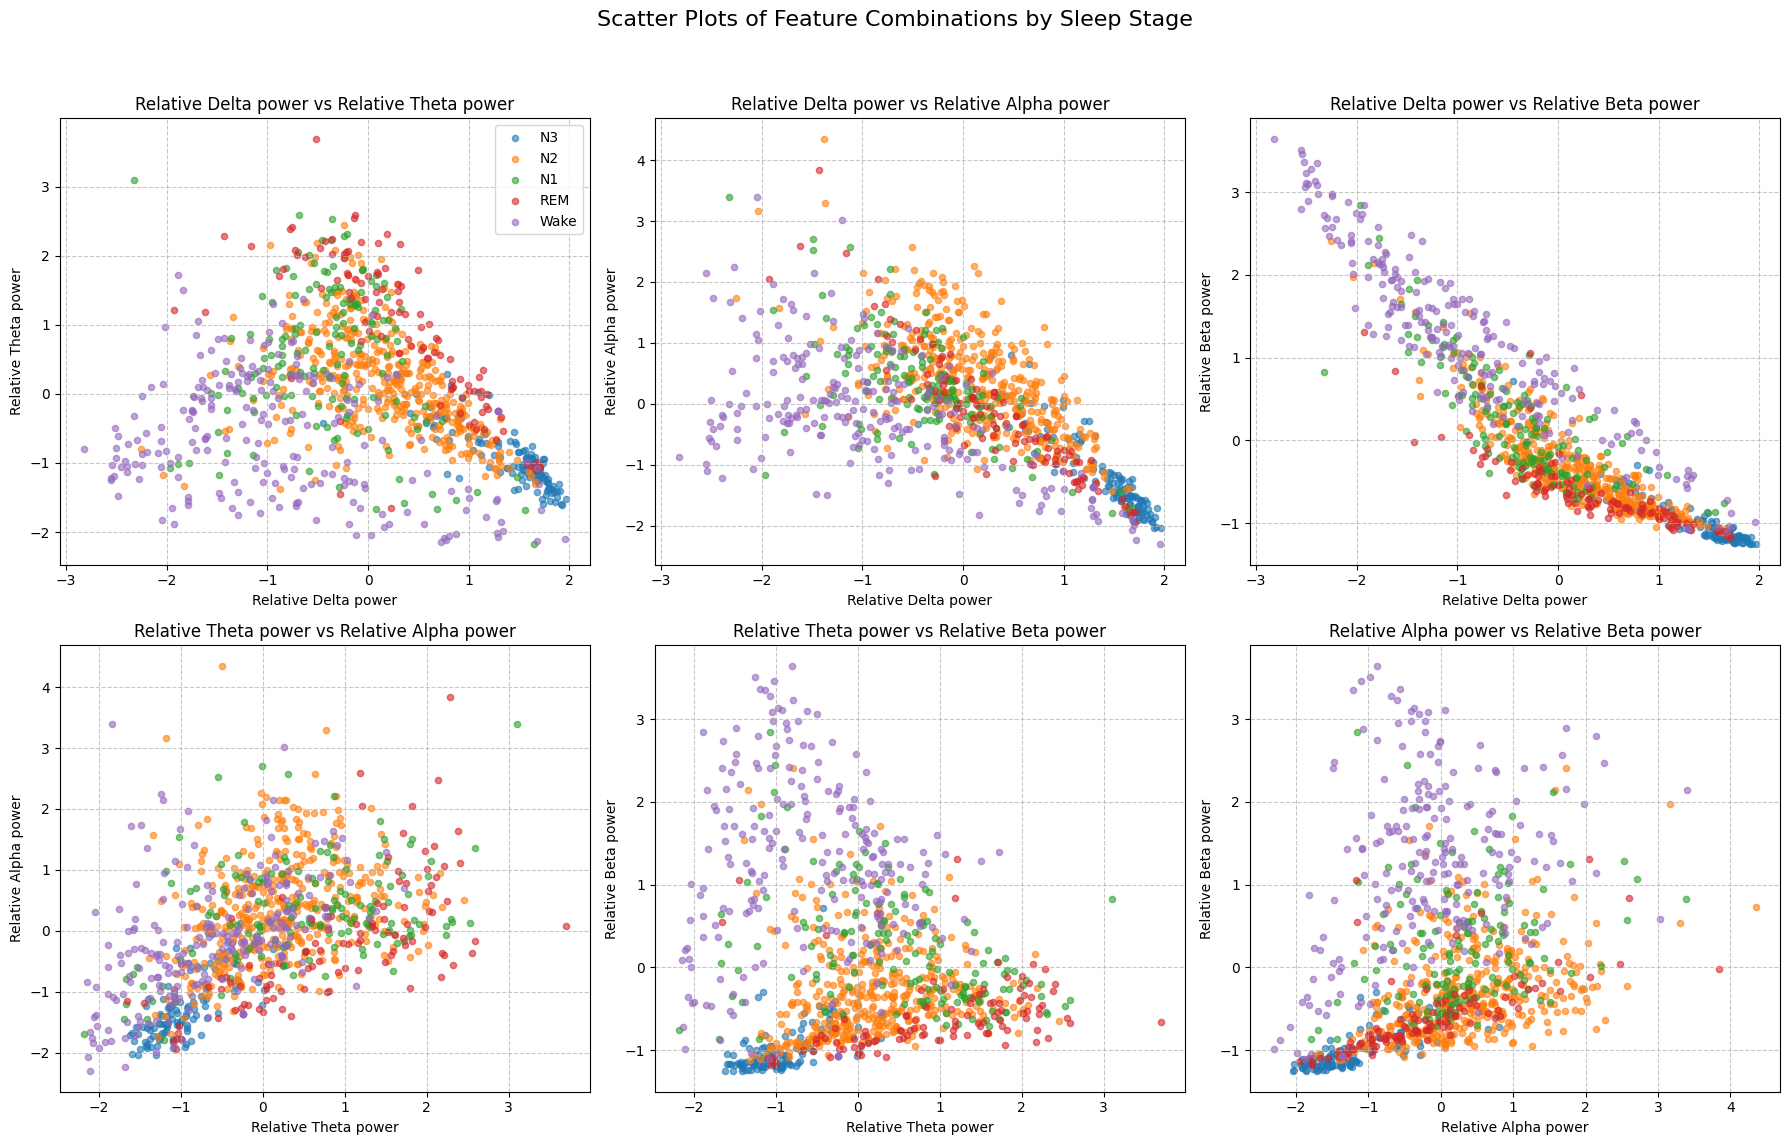

In [ ]:
fig = visualize_all_feature_pairs(
    features,
    labels,
    feature_names,
    sleep_stages,
    max_plots=6
)


  - Which sleep stages are easiest to discriminate?
  - Is it possible to find a linear separation between the classes?


**Make boxplots of the feature values of every sleep stage for each feature** (make 1 figure with 4 subplots, one per feature).
- Which features are the best to perform sleep stage classification?

Hint: use **matplotlib.pyplot.boxplot** to create a boxplot, which takes a list of (one-dimensional) NumPy arrays as input (one array). Have a look at the parameter `tick_labels`.

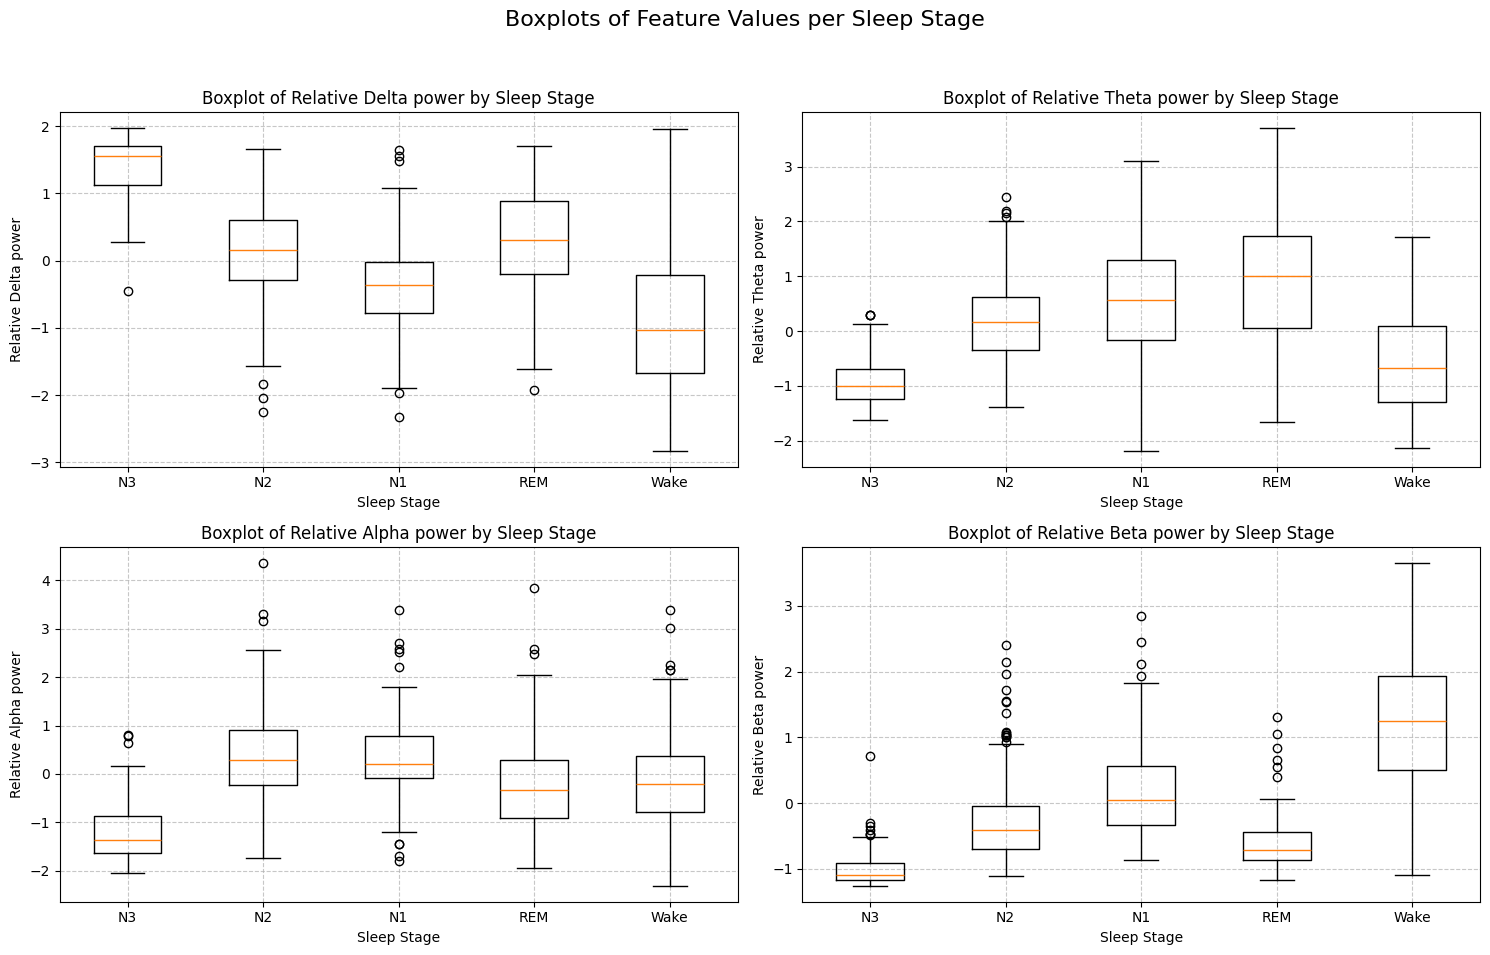

In [ ]:

def plot_feature_boxplots(
    features,
    labels,
    feature_names,
    sleep_stages,
    ncols=2,
    figsize=(15, 10)
):
    """
    Create boxplots of each feature grouped by sleep stage.
    """

    n_features = len(feature_names)
    nrows = int(np.ceil(n_features / ncols))

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
    axes = axes.flatten()

    for i, feature_name in enumerate(feature_names):
        ax = axes[i]

        # Collect data for each stage
        data_to_plot = []
        for j, stage in enumerate(sleep_stages):
            stage_data = features[labels == (j + 1), i]
            data_to_plot.append(stage_data)

        # Draw boxplot
        ax.boxplot(data_to_plot, tick_labels=sleep_stages)
        ax.set_title(f"Boxplot of {feature_name} by Sleep Stage")
        ax.set_xlabel("Sleep Stage")
        ax.set_ylabel(feature_name)
        ax.grid(True, linestyle="--", alpha=0.7)

    # Hide empty subplots (if any)
    for k in range(n_features, len(axes)):
        axes[k].axis("off")

    fig.suptitle("Boxplots of Feature Values per Sleep Stage", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.close(fig)

    return fig

def visualize_boxplots(features, labels, feature_names, sleep_stages):
    return plot_feature_boxplots(
        features=features,
        labels=labels,
        feature_names=feature_names,
        sleep_stages=sleep_stages
    )

visualize_boxplots(features, labels, feature_names, sleep_stages)


In [39]:
# plt.boxplot

## 1.3 Feature statistics

**Compute the mean and the standard deviation of the feature values for each class.** Generate a **table** to display your results in the notebook. This means one table to report the mean and one to report the standard deviations of each feature per class (columns: features, rows: classes).

Some useful functions:
- from the package *numpy*:
    - **mean**: compute mean of a vector
    - **std**: compute standard deviation of a vector
- from the package *pandas*:
    - **DataFrame**: convert array to table

In [40]:

def compute_feature_statistics(features, labels, feature_names, sleep_stages):
    """
    Compute mean and std for each feature across all sleep stages.

    Returns:
        mean_df: DataFrame of mean(feature) per stage
        std_df:  DataFrame of std(feature) per stage
    """

    n_stages = len(sleep_stages)
    n_features = len(feature_names)

    mean_matrix = np.zeros((n_stages, n_features))
    std_matrix  = np.zeros((n_stages, n_features))

    # Loop through all classes to compute the mean and the standard deviation for each feature and class
    for i, stage in enumerate(sleep_stages):
        stage_data = features[labels == (i + 1)]
        mean_matrix[i, :] = np.mean(stage_data, axis=0)
        std_matrix[i, :]  = np.std(stage_data, axis=0)

    # Create the tables (rows = sleep stages, columns = features)
    mean_df = pd.DataFrame(mean_matrix, index=sleep_stages, columns=feature_names)
    std_df  = pd.DataFrame(std_matrix,  index=sleep_stages, columns=feature_names)

    return mean_df, std_df


def summarize_features(features, labels, feature_names, sleep_stages, show=True):
    mean_df, std_df = compute_feature_statistics(
        features, labels, feature_names, sleep_stages
    )

    if show:
        print("\nMean of Feature Values per Sleep Stage:")
        display(mean_df)

        print("\nStandard Deviation of Feature Values per Sleep Stage:")
        display(std_df)

    return mean_df, std_df



mean_df, std_df = summarize_features(
    features, labels, feature_names, sleep_stages
)



Mean of Feature Values per Sleep Stage:


,Relative Delta power,Relative Theta power,Relative Alpha power,Relative Beta power
N3,1.392321,-0.925448,-1.185638,-0.992423
N2,0.137434,0.178867,0.355855,-0.295299
N1,-0.388657,0.502434,0.308305,0.201449
REM,0.303874,0.896572,-0.182806,-0.597345
Wake,-0.873118,-0.607077,-0.153741,1.219973



Standard Deviation of Feature Values per Sleep Stage:


,Relative Delta power,Relative Theta power,Relative Alpha power,Relative Beta power
N3,0.439970,0.436510,0.628675,0.276463
N2,0.640369,0.732913,0.852590,0.553179
N1,0.641484,1.021787,0.811708,0.684758
REM,0.740058,1.070668,1.011319,0.445234
Wake,1.076716,0.865428,0.979415,1.069844


from matplotlib import pyplot as plt
mean_df['Relative Delta power'].plot(kind='hist', bins=20, title='Relative Delta power')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_13['index'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_13, x='Relative Theta power', y='index', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_14['index'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_14, x='Relative Alpha power', y='index', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_15['index'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_15, x='Relative Beta power', y='index', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

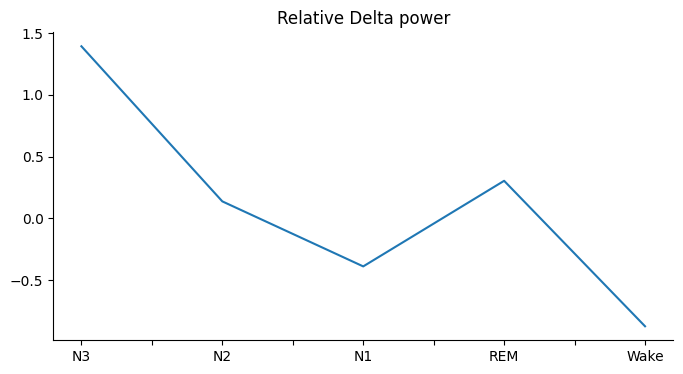

In [41]:
from matplotlib import pyplot as plt
mean_df['Relative Delta power'].plot(kind='line', figsize=(8, 4), title='Relative Delta power')
plt.gca().spines[['top', 'right']].set_visible(False)

Looking at the *mean values*, we can observe some interesting trends:

  - **N3 (Deep Sleep)**: Tends to have the highest 'Relative Delta power' and lowest 'Relative Theta power' and 'Relative Alpha power'. This aligns with the understanding that delta waves are prominent during deep sleep.
  - **REM (Rapid Eye Movement Sleep)**: Shows relatively high 'Relative Theta power' and lower 'Relative Alpha power' and 'Relative Beta power'.
  - **Wake:** Exhibits the highest 'Relative Beta power' and the lowest 'Relative Delta power', which is expected as beta waves are associated with an awake, active brain state.

Regarding the *standard deviation*, it gives us an idea of the variability within each sleep stage for each feature. A smaller standard deviation indicates that the feature values for that stage are tightly clustered around the mean, while a larger one suggests more spread. For instance, 'Relative Delta power' in N3 has a relatively low standard deviation, indicating consistency in delta power during deep sleep, while 'Relative Beta power' in Wake has a higher standard deviation, suggesting more variability in beta power during wakefulness.